# Aufgabe 3

In AUfgabe 3 hat sich der Schaltplan leicht geändert und es kam eine Avalanche-Diode vor, anstatt einer herkömlichen Halbleiterdiode, die vorher genutzt wurden.

![Aufbau des Schaltplans, entnommen von dem Moodel Experimentier DOkument](./Schaltung2.png)

Dabei wurde in der Schaltung eine Spule von $220 ~ \text{mH}$ genutzt. Da diese diese viel rauschen in die Lissajous-Figuren gebracht haben, war es nicht immer einfach eine genaue Gerade zu ahben. Man hatte auf dem Ossziloskop eher eine dicke Linie.

## Grafische Darstellung der Daten

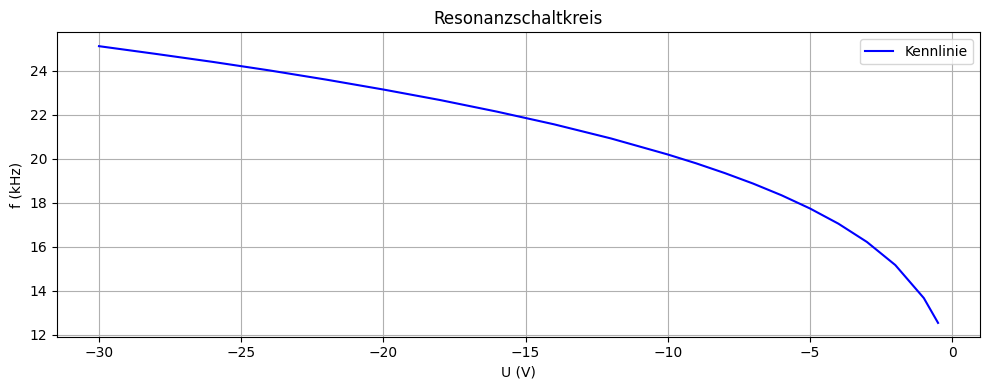

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_csv('Messungen/Aufgabe3.csv')
df.columns = df.columns.str.replace('"', '').str.strip()


# Plots
plt.figure(figsize=(10, 4))
plt.plot(df['U [V]'], df['f [kHz]'], label="Kennlinie", color="blue")
plt.xlabel("U (V)")
plt.ylabel("f (kHz)")
plt.title("Resonanzschaltkreis")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Tabelarische Darstellung der Daten


|    |    U [V] |   f [kHz] |       C_s_F |   C_s_pF |     C_tot_F |   C_tot_pF |
|---:|---------:|----------:|------------:|---------:|------------:|-----------:|
|  0 |  -0.5    |    12.55  | 6.76594e-10 |  676.594 | 7.31021e-10 |    731.021 |
|  1 |  -1      |    13.677 | 5.70732e-10 |  570.732 | 6.15511e-10 |    615.511 |
|  2 |  -2.003  |    15.177 | 4.54248e-10 |  454.248 | 4.99857e-10 |    499.857 |
|  3 |  -3.0025 |    16.227 | 3.88764e-10 |  388.764 | 4.37261e-10 |    437.261 |
|  4 |  -4.0024 |    17.055 | 3.45292e-10 |  345.292 | 3.95835e-10 |    395.835 |
|  5 |  -5.0025 |    17.746 | 3.1375e-10  |  313.75  | 3.65609e-10 |    365.609 |
|  6 |  -6.0022 |    18.346 | 2.89532e-10 |  289.532 | 3.42086e-10 |    342.086 |
|  7 |  -7.0022 |    18.877 | 2.7017e-10  |  270.17  | 3.23111e-10 |    323.111 |
|  8 |  -8.0014 |    19.355 | 2.54248e-10 |  254.248 | 3.07349e-10 |    307.349 |
|  9 |  -9.0014 |    19.795 | 2.40836e-10 |  240.836 | 2.93837e-10 |    293.837 |
| 10 | -10.0015 |    20.198 | 2.29343e-10 |  229.343 | 2.82228e-10 |    282.228 |
| 11 | -12.001  |    20.927 | 2.10569e-10 |  210.569 | 2.62908e-10 |    262.908 |
| 12 | -14      |    21.568 | 1.95764e-10 |  195.764 | 2.47513e-10 |    247.513 |
| 13 | -16.001  |    22.142 | 1.83688e-10 |  183.688 | 2.34846e-10 |    234.846 |
| 14 | -17.999  |    22.669 | 1.73615e-10 |  173.615 | 2.24054e-10 |    224.054 |
| 15 | -20      |    23.148 | 1.65025e-10 |  165.025 | 2.14877e-10 |    214.877 |
| 16 | -22      |    23.596 | 1.57599e-10 |  157.599 | 2.06795e-10 |    206.795 |
| 17 | -24      |    24.015 | 1.51093e-10 |  151.093 | 1.99642e-10 |    199.642 |
| 18 | -25.998  |    24.403 | 1.45336e-10 |  145.336 | 1.93344e-10 |    193.344 |
| 19 | -27.999  |    24.766 | 1.40184e-10 |  140.184 | 1.87718e-10 |    187.718 |
| 20 | -29.997  |    25.117 | 1.3555e-10  |  135.55  | 1.82508e-10 |    182.508 |

: Angabe der Werte für $C_s(U)$ in einer Tabelle

In [7]:
# Berechneten Werte für die Tabelle
def Cs(U, C0, UD):
    return C0 * np.sqrt(UD/(UD-U))

def C_tot(f, L = 220e-3):
    return 1/(L * 4 * (np.pi * f)**2)

def d_0(A=25e-6, C0=2e-6):
    epsilon_r = 11.3
    epsilon_0 = 8.854e-12
    return epsilon_r * epsilon_0 * (A/C0)

# Tabelle mit Cs(U) und aus f berechneten C_tot
C0_fit = popt[0]
UD_fit = popt[1]
df_table = df.copy()
df_table['C_s_F'] = Cs(df_table['U [V]'].values, C0_fit, UD_fit)
df_table['C_s_pF'] = df_table['C_s_F'] * 1e12
df_table['C_tot_F'] = C_tot(df_table['f [kHz]'].values * 1000)
df_table['C_tot_pF'] = df_table['C_tot_F'] * 1e12
pd.options.display.float_format = '{:,.3f}'.format
df_table[['U [V]', 'f [kHz]', 'C_tot_pF', 'C_s_pF']]
#print(df_table.to_markdown())
print("")

## Fit von $C_\text{tot}$

Wir nutzen für den Fit die folgende Formel

$$C_\text{tot} = C_G + \frac{C_0}{\sqrt{1-U/U_D}}$$

Mit dem können wir alle die wichtigen Werte bestimmen. $d_0$, bei der Spannung $U=0V$ ergibt sich dann wie folgt:

$$d_0 = \varepsilon_r \varepsilon_0 \frac{A}{C_0}$$

wobei wir folgende Werte aus der Experimentierbeschreibung schon gegeben haben.

$A = 25 \text{mm}²$ als Fläche des Kondensators, $\varepsilon_r = 11.8$ als relative Permittivität des Siliziums und $\varepsilon_0 = 8.854 \cdot 10^{-12}$ als Naturkonstante bekonnt ist

Damit können wir alle nötigen Werte bestimmen.

AUFGABE 3: Ergebnisse vom Fit

Fit-Ergebnisse:
  C_0 (Sperrschicht bei 0V) = 0.877 nF (±0.007 nF)
  U_D (Diffusionsspannung) = 0.7334 V  (±0.0262 V)
  C_G (Gehäusekapazität)   = 50.28 pF (±2.45 pF)

──────────────────────────────────────────────────────────────────────
PHYSIKALISCHE PARAMETER:
──────────────────────────────────────────────────────────────────────
Sperrschichtweite d_0 (bei U=0): 2.977 µm


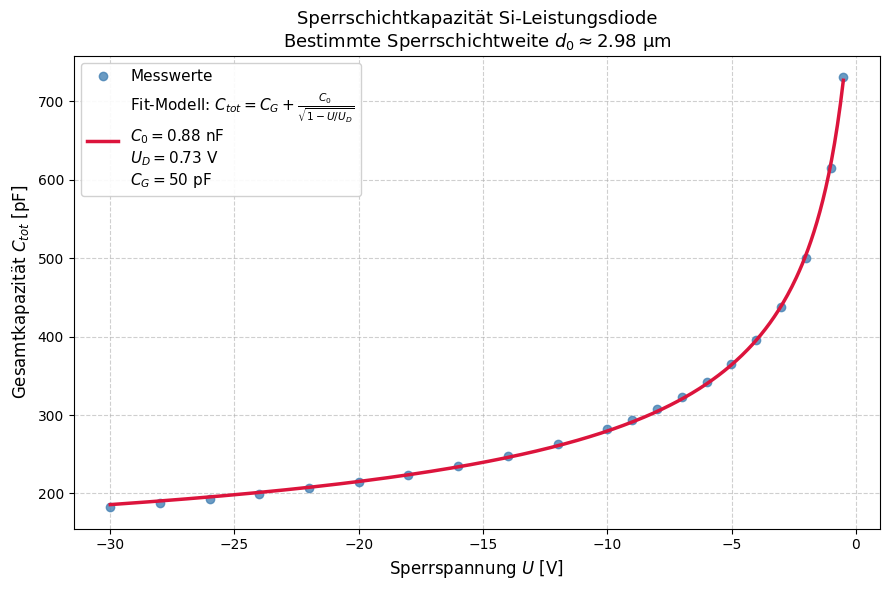

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

# Daten laden
df = pd.read_csv('Messungen/Aufgabe3.csv')
df.columns = df.columns.str.replace('"', '').str.strip()

U_meas = df['U [V]'].values  # Spannung in V (sollte negativ sein für Sperrrichtung)
f_meas = df['f [kHz]'].values * 1000  # Frequenz in Hz

# ============================================================================
# SCHRITT 1: Berechnung der Gesamtkapazität aus Resonanzfrequenz
# ============================================================================
L = 220e-3  # Induktivität in H (220 mH)
# Thomson-Formel nach C umgestellt: C = 1 / (L * omega^2)
C_tot = 1 / (L * (2 * np.pi * f_meas)**2)

print("="*70)
print("AUFGABE 3: Ergebnisse vom Fit")
print("="*70)
# ============================================================================
# SCHRITT 2: Nichtlinearer Fit (3 Parameter: C0, UD, CG)
# ============================================================================

def varaktor_model_complete(U, C0, UD, CG):
    """
    Modell für Gesamtkapazität einer Diode in Sperrrichtung.
    U: Spannung (negativ)
    C0: Sperrschichtkapazität bei U=0
    UD: Diffusionsspannung
    CG: Gehäusekapazität (parasitär, konstant)
    """
    # Formel: C_tot = C_G + C0 / sqrt(1 - U/UD)
    return CG + C0 / np.sqrt(1 - U/UD)

# Startwerte schätzen (damit der Fit nicht im Dunkeln tappt)
C0_init = 1.6e-9   # ca 1.7 nF
UD_init = 0.5      # ca 0.6 V (Standard Si)
CG_init = 80e-12   # ca 80 pF

# Fit durchführen
# Bounds: C0>0, 0.1<UD<2.0, CG>0
popt, pcov = curve_fit(
    varaktor_model_complete,
    U_meas,
    C_tot,
    p0=[C0_init, UD_init, CG_init],
    #bounds=([1e-12, 0.1, 0], [1e-5, 5.0, 1e-9]),
    maxfev=100000
)

C0_fit, UD_fit, CG_fit = popt
perr = np.sqrt(np.diag(pcov))

# R^2 berechnen (Qualität des Fits)
C_fit_calc = varaktor_model_complete(U_meas, *popt)
ss_res = np.sum((C_tot - C_fit_calc)**2)
ss_tot = np.sum((C_tot - np.mean(C_tot))**2)
r_squared = 1 - (ss_res / ss_tot)

print(f"\nFit-Ergebnisse:")
print(f"  C_0 (Sperrschicht bei 0V) = {C0_fit*1e9:.3f} nF (±{perr[0]*1e9:.3f} nF)")
print(f"  U_D (Diffusionsspannung) = {UD_fit:.4f} V  (±{perr[1]:.4f} V)")
print(f"  C_G (Gehäusekapazität)   = {CG_fit*1e12:.2f} pF (±{perr[2]*1e12:.2f} pF)")
#print(f"  Bestimmtheitsmaß R²      = {r_squared:.5f}")

# ============================================================================
# SCHRITT 3: Berechnung der Sperrschichtweite d0
# ============================================================================
epsilon_r = 11.8       # Silizium (Standardwert, 11.3 ist manchmal für Ge angegeben, Si ist meist 11.8 oder 11.9)
epsilon_0 = 8.854e-12  # As/Vm
A_diode = 25e-6        # Fläche in m^2 (25 mm^2)

# Formel: C0 = eps_0 * eps_r * A / d0  => d0 = eps_0 * eps_r * A / C0
d_0 = (epsilon_r * epsilon_0 * A_diode) / C0_fit

print(f"\n{'─'*70}")
print("PHYSIKALISCHE PARAMETER:")
print(f"{'─'*70}")
print(f"Sperrschichtweite d_0 (bei U=0): {d_0*1e6:.3f} µm") 

# ============================================================================
# SCHRITT 4: PLOT
# ============================================================================
fig, ax = plt.subplots(figsize=(9, 6))

# Glatte Kurve für den Fit zeichnen
U_smooth = np.linspace(U_meas.min(), U_meas.max(), 500)
C_smooth = varaktor_model_complete(U_smooth, C0_fit, UD_fit, CG_fit)

# Messpunkte
ax.plot(U_meas, C_tot*1e12, 'o', color='steelblue', label='Messwerte', 
        markersize=6, alpha=0.8, zorder=3)

# Fit-Kurve
label_text = (f'Fit-Modell: $C_{{tot}} = C_G + \\frac{{C_0}}{{\\sqrt{{1 - U/U_D}}}}$\n'
              f'$C_0 = {C0_fit*1e9:.2f}$ nF\n'
              f'$U_D = {UD_fit:.2f}$ V\n'
              f'$C_G = {CG_fit*1e12:.0f}$ pF')

ax.plot(U_smooth, C_smooth*1e12, '-', color='crimson', linewidth=2.5, 
        label=label_text, zorder=4)

# Achsenbeschriftung und Design
ax.set_xlabel('Sperrspannung $U$ [V]', fontsize=12)
ax.set_ylabel('Gesamtkapazität $C_{tot}$ [pF]', fontsize=12)
ax.set_title(f'Sperrschichtkapazität Si-Leistungsdiode\nBestimmte Sperrschichtweite $d_0 \\approx {d_0*1e6:.2f}$ µm', fontsize=13)
ax.grid(True, which='both', linestyle='--', alpha=0.6)
ax.legend(fontsize=11, loc='upper left', frameon=True, fancybox=True, framealpha=0.9)

plt.tight_layout()
plt.show()

Die durchgeführte Auswertung bestätigt eine nichtlineare Kennlinie, beschrieben durch $C_\text{tot} = C_G + \frac{C_0}{\sqrt{1-U/U_D}}$. Der nichtlineare Fit liefert $C_0 = 0.877 \text{nF}\ (\pm0.007 \text{nF})$, $U_D = 0.7334 \text{V} (\pm0.0263\ \text{V})$ und als Gehäusekapazität $C_G = 50.28 \text{pF} \pm 2.45 \text{pF}$. Aus $C_0$ folgt eine Sperrschichtdicke bei $U=0$ von ca. $d_0 = 2.977 \mu\text{m}$.
